In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures





In [7]:
url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

df.head()               #display first five rows

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [10]:
X = df[['displacement']]
y= df['mpg']
print("Missing values in Displacement:",X.isnull().sum())
print("Missing Values in MPG:",y.isnull().sum())


      







Missing values in Displacement: displacement    0
dtype: int64
Missing Values in MPG: 0


In [11]:
data = df[['displacement','mpg']].dropna()

X = data[['displacement']]
y = data['mpg']

print("Feature:")
print(X.head())

print("\n Target:")
print(y.head())



Feature:
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0

 Target:
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


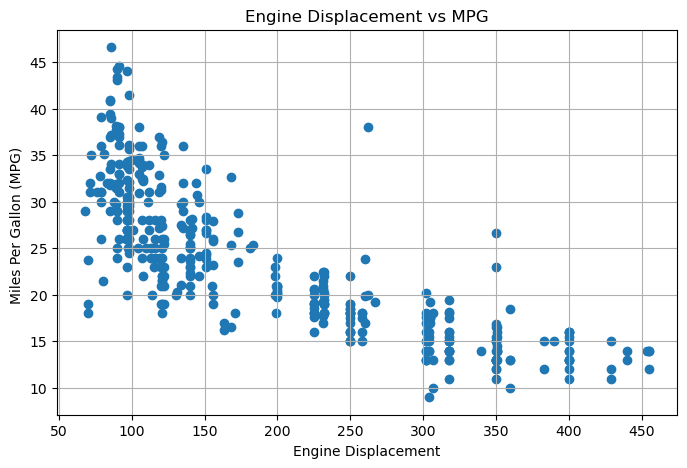

In [13]:
plt.figure(figsize=(8,5))

plt.scatter(X , y)

plt.xlabel("Engine Displacement")
plt.ylabel("Miles Per Gallon (MPG) ")
plt.title("Engine Displacement  vs MPG")

plt.grid(True)
plt.show()

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,  #for training 
    random_state=42  #for testing
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 318
Testing Samples: 80


In [17]:
linear_model = LinearRegression() #create Linear Regression Model

linear_model.fit(X_train, y_train)  #train the model

y_pred_linear = linear_model.predict(X_test) #predict on test data




In [18]:
mse_linear = mean_squared_error(y_test, y_pred_linear)

r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("    -------------  ")
print("MSE:",mse_linear)
print("R-Squared:",r2_linear)

Linear Regression Results
    -------------  
MSE: 18.102543998358946
R-Squared: 0.6633114869465595


In [35]:
results = []
polynomial_model = {}

results.append({
    'Model': 'Linear Regression',
    'Degree': 1,
    'MSE': mse_linear,
    'R-Squared': r2_linear
})

for degree in range(2, 6):

    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    poly_model = LinearRegression()

    poly_model.fit(X_train_poly, y_train)

    y_pred_poly = poly_model.predict(X_test_poly)

    mse = mean_squared_error(y_test, y_pred_poly)
    r2 = r2_score(y_test, y_pred_poly)

    results.append({
        'Model': 'Polynomial Regression',
        'Degree': degree,
        'MSE': mse,
        'R-Squared': r2
         })

    polynomial_model[degree] = {
        'poly': poly,
        'model': poly_model
        }


In [36]:
results_df = pd.DataFrame(results)

results_df

,Model,Degree,MSE,R-Squared
0,Linear Regression,1,18.102544,0.663311
1,Polynomial Regression,2,15.107354,0.719019
2,Polynomial Regression,3,14.943632,0.722064
3,Polynomial Regression,4,14.961487,0.721732
4,Polynomial Regression,5,15.230896,0.716721


NameError: name 'polynomail_models' is not defined

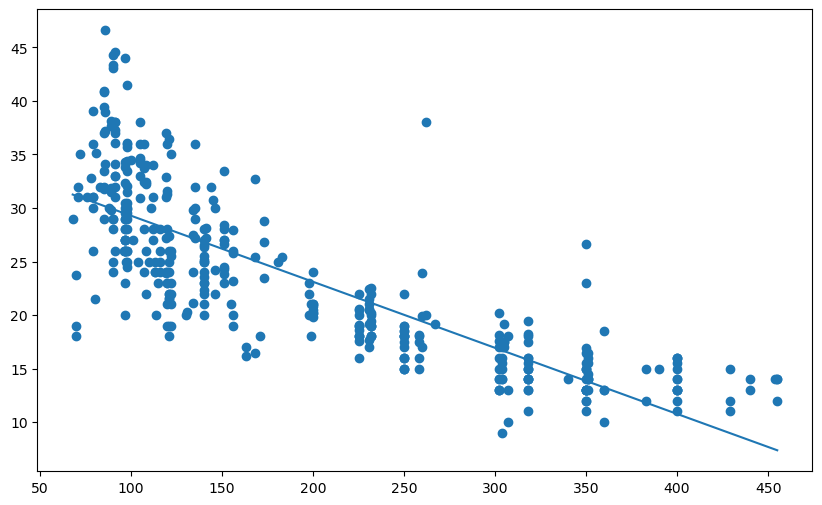

In [38]:
X_plot = pd.DataFrame({
    'displacement':np.linspace(
        X['displacement'].min(),
        X['displacement'].max(),
        300
    )
})
plt.figure(figsize=(10,6))

plt.scatter(
    X['displacement'],
    y,
    label='Actual Data'
)
y_plot_linear = linear_model.predict(X_plot)
plt.plot(
    X_plot['displacement'],
    y_plot_linear,
    label='Linear Regression'
)


for degree in range(2,6):
    poly = polynomial_model[degree]['poly']
    poly_model=polynomail_models[degree]['model']
    X_plot_poly = poly_model.predict(X_plot_poly)
    y_plot_poly = poly_model.predict(X_plot_poly)
    plt.plot(
        X_plot['displacement'],
        y_plot_poly,
    label=f'polynomial degree(degree)'
    )
    
plt.xlabel('Engine Displacement')
plt.ylabel('Miles Per Gallon (MPG)')

plt.title(
        'Linear and Polynomial Regression :Displacement v/s MPG'
    )

plt.lengend()
plt.grid(True)
plt.show()


    


    

In [ ]:
plt.figure(figsize)=(8,5)
plt.plot(
    results_df['Degree'],
    results-df['R-Squared'],
    maeker = 'y',
)

plt.xlabel("Polynomail Degree")
plt.ylabel("R-Squared")
plt.tilte("Comparison of R-Squared")

    

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(results_df['Degreee'].astype(str),
         results_df['MSE']
        )

plt